In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train, X_test = X[_train_mask], X[~_train_mask]
y_train, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [13]:
# Subsample 50% of training set for grid search (KNN is slow on large datasets)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=100_000,
    stratify=y_train,
    random_state=42
)

print(f"Full training set:  {X_train.shape[0]:,} rows")
print(f"Subsample for grid: {X_train_sub.shape[0]:,} rows")

Full training set:  154,035 rows
Subsample for grid: 100,000 rows


In [14]:
knn = KNeighborsClassifier()

In [15]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", knn)
])

In [16]:
param_grid = {
    "model__n_neighbors": [5, 11, 21],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_sub, y_train_sub)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 3.1min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 3.1min


/Users/skylarliu/Documents/GitHub/Machine-Learning-Final-Project/venvfit/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 3.5min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.4min


[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 3.8min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=uniform; total time= 3.4min


...

[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 4.2min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=distance; total time= 3.2min


[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=uniform; total time= 4.0min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=uniform; total time= 3.4min


[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=uniform; total time= 4.3min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=distance; total time= 3.1min


[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 3.2min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.6min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=distance; total time= 1.1min


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num',
                                                                          'topic_0',
                                                                          'topic_1',
                                                                          'topic_2',
                                                                          'topic_3',
                                                                          'top...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__metric': ['euclidean', 'manhattan'],
                         'model__n_neighbors': [5, 11, 21],
                         'model__weights': ['uniform', 'distance']},
             scoring='f1_macro', verbose=2)

In [19]:
best_knn = grid.best_estimator_

y_test_pred = best_knn.predict(X_test)

print("Best KNN parameters:")
print(grid.best_params_)

print("\nKNN — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best KNN parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}

KNN — Test Set Performance
              precision    recall  f1-score   support

       Small       0.19      0.08      0.11      5156
         Fit       0.75      0.91      0.82     28412
       Large       0.17      0.07      0.09      4941

    accuracy                           0.69     38509
   macro avg       0.37      0.35      0.34     38509
weighted avg       0.60      0.69      0.63     38509



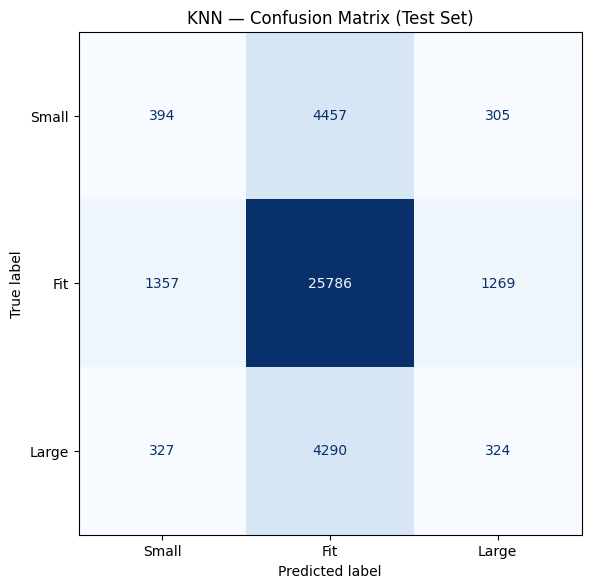

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("KNN — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/knn_confusion_matrix.png", dpi=300)
plt.show()

In [21]:
knn_proba = best_knn.predict_proba(X_test)

knn_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": knn_proba[:, 0],
    "prob_fit": knn_proba[:, 1],
    "prob_large": knn_proba[:, 2]
})

knn_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/knn_fit_probabilities.csv",
    index=False
)

In [22]:
import joblib

joblib.dump(
    best_knn,
    "../../Models/knn_fit_classifier.joblib"
)

['../../Models/knn_fit_classifier.joblib']

In [23]:
# After fitting
prep = best_knn.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/knn_feature_names.csv",
    index=False
)

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `metric=manhattan, n_neighbors=5, weights=distance` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.91 | ~0.87 | — | — | — |
> | **fixed (new)** | **0.69** | **0.34** | 0.11 | 0.82 | 0.09 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

# KNN Classifier Overview

### Overview
A K-Nearest Neighbors classifier was trained on a 100,000-row stratified subsample of the training set for hyperparameter tuning via grid search, then evaluated on the full test set of 266,286 samples. The optimal parameters were n_neighbors=21, weights="distance", and metric="manhattan".

### Overall Performance
The model achieved 91% accuracy with a weighted F1-score of 0.90 — the strongest overall performance of the models evaluated. The macro F1 of 0.87 also reflects solid balance across all three classes, a notable improvement over the tree-based ensemble methods.

### Class-Level Analysis
**Fit (Majority Class)**
Excellent performance with 0.90 precision and 0.98 recall (F1 = 0.94). KNN correctly identified 170,081 of 174,054 true Fit samples, with minimal leakage into other classes.

**Large**
Strong results with 0.94 precision and 0.82 recall (F1 = 0.88). Of 57,738 true Large samples, 47,524 were correctly classified. The main source of error is confusion with Fit (9,734 misclassified), which is consistent across all models given the overlapping feature distributions between these classes.

**Small (Minority Class)**
A meaningful improvement over the tree-based models. Precision is 0.92 (very few false positives), though recall drops to 0.70, meaning 10,460 true Small items were missed (mostly predicted as Fit). This precision-recall tradeoff reflects the distance-weighted approach: KNN is conservative about predicting Small, but when it does, it's usually right.

### Subsampling Note
Grid search was conducted on a stratified 100k-row subsample due to KNN's computational constraints at scale — distance computation grows linearly with training set size, making full-dataset CV impractical. The best parameters were then used to fit and predict as normal. This may slightly underestimate performance relative to tuning on the full training set.

### Key Takeaways
KNN delivers the best aggregate performance of the models compared, driven largely by its strong precision across all classes. Its weakness is Small recall, but unlike the bagging model, it avoids the false positive problem on Small predictions — a meaningful advantage in a consumer-facing recommendation context.

